In [1]:
import pandas as pd
df = pd.read_csv('../../02_Data/processed/real_final_ml.csv')

c:\Users\seon\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\seon\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
df = df.drop(columns=['enableBoardGameProperties','projectID','campaignGoal_usd_6m','fundsGathered_usd_6m','price_usd_6m','is_backer_0','is_backer_1'])

In [3]:
for i in df.columns:
    print(i)

minPlayers
maxPlayers
minAge
playTime
fundedInSeconds
isDiscounted
previous_campaigns_count
duration_days
softclose
campaignGoal_usd_1m
fundsGathered_usd_1m
price_usd_1m
edge_density
saturation
brightness
contrast
rewards_count
R1
G1
B1
R2
G2
B2
R3
G3
B3
R4
G4
B4
ks_color_1
ks_color_2
ks_color_3
ks_color_4
emotion_adjective_1
emotion_adjective_2
emotion_adjective_3
emotion_adjective_4
creator_id_0
creator_id_1
is_pledge_master_0
is_pledge_master_1
is_prior_backer_0
is_prior_backer_1
is_pathfinder_0
is_pathfinder_1
is_normal_0
is_normal_1
likes_0
likes_1
Product_Question_count_0
Product_Question_count_1
Suggestion_Idea_count_0
Suggestion_Idea_count_1
Praise_Support_count_0
Praise_Support_count_1
Shipping_Fulfillment_count_0
Shipping_Fulfillment_count_1
Complaint_Refund_count_0
Complaint_Refund_count_1
Spam_Irrelevant_count_0
Spam_Irrelevant_count_1
긍정_0
긍정_1
부정_0
부정_1
중립_0
중립_1
Campaign / Pledge_0
Campaign / Pledge_1
Community Reaction_0
Community Reaction_1
Components & Production_0
Co

In [ ]:
import numpy as np
import pandas as pd

#
col_name = 'fundsGathered_usd_1m'

# 각 조건별 describe 추출
s_all = df[col_name].describe()
s_1m = df[df[col_name] < 1000000][col_name].describe()
s_2m = df[df[col_name] < 2000000][col_name].describe()

# 마크다운 표 구조 자동 생성 및 출력
print(f"| 지표 | 초극단값 포함 (n={s_all['count']:.0f}) | 100만 불 컷오프 후 (n={s_1m['count']:.0f}) | 200만 불 컷오프 후 (n={s_2m['count']:.0f}) | 변화 및 의미 |")
print("| :---: | :---: | :---: | :---: | :--- |")
print(f"| **Max (최댓값)** | ${s_all['max']:,.2f} 달러 | ${s_1m['max']:,.2f} 달러 | ${s_2m['max']:,.2f} 달러 | 초극단값 격리 수준 대조 |")
print(f"| **Std (표준편차)** | ${s_all['std']:,.2f} 달러 | ${s_1m['std']:,.2f} 달러 | ${s_2m['std']:,.2f} 달러 | 데이터 변동성 완화 추이 비교 |")
print(f"| **Mean (평균)** | ${s_all['mean']:,.2f} 달러 | ${s_1m['mean']:,.2f} 달러 | ${s_2m['mean']:,.2f} 달러 | 우측 왜도(Skewness) 완화 증거 |")
print(f"| **50% (중위수)** | ${s_all['50%']:,.2f} 달러 | ${s_1m['50%']:,.2f} 달러 | ${s_2m['50%']:,.2f} 달러 | 일반 창작자 중심점 유지 여부 |")

| 지표 | 초극단값 포함 (n=483) | 100만 불 컷오프 후 (n=442) | 200만 불 컷오프 후 (n=462) | 변화 및 의미 |
| :---: | :---: | :---: | :---: | :--- |
| **Max (최댓값)** | $11,912,581.98 달러 | $941,398.20 달러 | $1,886,509.54 달러 | 초극단값 격리 수준 대조 |
| **Std (표준편차)** | $1,120,484.49 달러 | $197,314.93 달러 | $325,637.67 달러 | 데이터 변동성 완화 추이 비교 |
| **Mean (평균)** | $378,070.88 달러 | $118,112.96 달러 | $172,765.92 달러 | 우측 왜도(Skewness) 완화 증거 |
| **50% (중위수)** | $35,687.55 달러 | $29,279.17 달러 | $32,301.68 달러 | 일반 창작자 중심점 유지 여부 |


In [13]:
df_iqr['fundsGathered_usd_1m'].describe()

count       418.000000
mean      82572.904219
std      131087.564373
min           0.000000
25%        2833.623026
50%       24614.931525
75%       87655.899917
max      540595.000873
Name: fundsGathered_usd_1m, dtype: float64

In [7]:
df.loc[df['fundsGathered_usd_1m']<1000000]['fundsGathered_usd_1m'].describe()

count       442.000000
mean     118112.957653
std      197314.928811
min           0.000000
25%        3179.350551
50%       29279.170441
75%      117333.027895
max      941398.200000
Name: fundsGathered_usd_1m, dtype: float64

In [11]:
df

,minPlayers,maxPlayers,minAge,playTime,fundedInSeconds,isDiscounted,previous_campaigns_count,duration_days,softclose,campaignGoal_usd_1m,...,Survival,TTRPG,Terrain Building,Tower Defense,Video Game,Video Game Theme,Wargame,WinterFeast2026,Worker placement,dinotuesday
0,1.0,4.0,14.0,60.0,628,0,0,31,1,10000.000000,...,1,0,0,0,0,0,1,0,0,1
1,1.0,4.0,13.0,90.0,2716,0,0,33,1,20000.000000,...,0,0,0,0,0,0,1,0,0,1
2,1.0,2.0,12.0,480.0,56442,1,1,31,0,7000.000000,...,0,0,0,0,0,0,1,0,0,0
3,2.0,5.0,8.0,15.0,2409627,0,0,28,0,300.000000,...,0,0,0,0,0,0,0,0,0,0
4,2.0,6.0,8.0,20.0,14439,0,0,43,1,1164.031818,...,0,0,0,0,0,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
478,2.0,4.0,14.0,180.0,0,0,0,21,0,23280.636364,...,0,0,0,0,0,0,1,0,0,0
479,2.0,4.0,5.0,25.0,0,1,0,30,0,11407.511818,...,0,0,0,0,0,0,0,0,0,0
480,1.0,4.0,14.0,30.0,0,1,0,16,0,11640.318182,...,0,0,0,0,0,0,0,0,0,0
481,2.0,4.0,12.0,120.0,0,0,0,33,0,23280.636364,...,0,0,1,0,0,0,0,0,0,0


In [9]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error

# 경고 메시지 숨기기 (numexpr, bottleneck 관련 경고 방지)
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 1. 유저 맞춤형 피처 그룹 정의 (제공해주신 변수명 100% 반영)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']

game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']

campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']

location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']

# 사진 정보 + RGB 물리 피처 (Low-level)
image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']

# 대표색 텍스트 + 대표 분위기 의미 피처 (High-level)
color_text = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4']
color_emotion = ['emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']

# 댓글 기본 정보 (메타 데이터)
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

# 댓글 텍스트 분석 3파전 그룹
comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
comment_topics = ['Campaign / Pledge_0', 'Campaign / Pledge_1', 'Community Reaction_0', 'Community Reaction_1', 'Components & Production_0', 'Components & Production_1', 'Gameplay / Rules / Content_0', 'Gameplay / Rules / Content_1', 'Language & Localization_0', 'Language & Localization_1', 'Schedule / Updates_0', 'Schedule / Updates_1', 'Shipping / Price / Tax_0', 'Shipping / Price / Tax_1']
comment_j = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']

# 게임 장르 및 테마 태그
game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# ======================================================================
# 2. 고정 뼈대(Base) 및 실험 축(X, Y) 세팅
# ======================================================================
# 고정 베이스 피처 세트 조립 (수치형 정보 + 댓글 메타)
base_features = performance + game_properties + campaign_info + location + comment_info

# [시각 정보 축] 저수준 물리 피처 조합 vs 고수준 의미 피처 조합
vis_options = {
    'Vis_Low (물리/RGB)': image_features + color_visual,
    'Vis_High (의미/감정)': color_text + color_emotion
}

# [텍스트 정보 축] 감성 3중분류 vs 도메인 주제분류 vs 제미나이 의도분류
txt_options = {
    'Txt_3C (기본감성)': comment_3c,
    'Txt_Topics (도메인주제)': comment_topics,
    'Txt_Gemini (유저의도)': comment_j
}

# [🚨 필수 확인] 'df' 자리에 아웃라이어가 제거된 본인의 최종 데이터프레임 변수명을 입력하세요.
y_all = df['fundsGathered_usd_1m'] 

# 5-Fold 교차 검증 객체 생성
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# 결과를 누적 기록할 리스트
experiment_results = []

print("🏁 [창작자 관점 토너먼트 가동] MAE(메인) & RMSE/MedAE(보조) 실험 시작...\n" + "="*85)

# ======================================================================
# 3. 2×3 매트릭스 다중 루프 연산 (6대 시나리오 전수 조사)
# ======================================================================
scenario_num = 1
for vis_name, vis_cols in vis_options.items():
    for txt_name, txt_cols in txt_options.items():
        
        # 이번 시나리오에 독립변수로 사용할 피처 최종 조립 (중복 제거)
        current_features = base_features + vis_cols + txt_cols + game_tags
        current_features = list(dict.fromkeys(current_features))
        
        X_current = df[current_features]
        
        # 각 폴드별 지표를 담을 리스트
        fold_mae_tr, fold_mae_te = [], []
        fold_medae_te, fold_rmse_te = [] ,[]
        
        for train_idx, test_idx in kf.split(X_current):
            X_tr, X_te = X_current.iloc[train_idx], X_current.iloc[test_idx]
            y_tr, y_te = y_all.iloc[train_idx], y_all.iloc[test_idx]
            
            # 소규모 데이터셋 과적합 제어용 규제 모델 선언
            model = RandomForestRegressor(max_depth=4, min_samples_leaf=8, max_features=0.4, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)
            
            # 예측값 생성
            tr_preds = model.predict(X_tr)
            te_preds = model.predict(X_te)
            
            # 지표 계산 및 적재
            fold_mae_tr.append(mean_absolute_error(y_tr, tr_preds))
            fold_mae_te.append(mean_absolute_error(y_te, te_preds))
            fold_medae_te.append(median_absolute_error(y_te, te_preds))
            fold_rmse_te.append(np.sqrt(mean_squared_error(y_te, te_preds)))
            
        # 5개 폴드 성적의 산술 평균 산출
        mean_mae_tr = np.mean(fold_mae_tr)
        mean_mae_te = np.mean(fold_mae_te)
        mean_medae_te = np.mean(fold_medae_te)
        mean_rmse_te = np.mean(fold_rmse_te)
        mae_gap = mean_mae_te - mean_mae_tr # 과적합 수치 추적
        
        print(f"🎬 Scenario {scenario_num}: [{vis_name}] + [{txt_name}]")
        print(f"   - 투입 피처 수 : {X_current.shape[1]}개")
        print(f"   - [🔥 메인] Test MAE   : {mean_mae_te:.2f} 달러 (과적합 갭: {mae_gap:.2f} 달러)")
        print(f"   - [🎯 보조] Test MedAE : {mean_medae_te:.2f} 달러 (창작자 체감 중간 오차)")
        print(f"   - [🛡️ 보조] Test RMSE  : {mean_rmse_te:.2f} 달러 (대형 오판 리스크 감시)")
        print("-" * 85)
        
        # 데이터프레임 변환용 기록
        experiment_results.append({
            'Scenario': f"S{scenario_num}",
            'Visual_Strategy': vis_name,
            'Text_Strategy': txt_name,
            'Features_Count': X_current.shape[1],
            'Train_MAE': mean_mae_tr,
            'Test_MAE': mean_mae_te,
            'MAE_Gap': mae_gap,
            'Test_MedAE': mean_medae_te,
            'Test_RMSE': mean_rmse_te
        })
        scenario_num += 1

# ======================================================================
# 4. 최종 리그 성적표 종합 및 정렬 (창작자 메인 지표인 Test MAE 기준 정렬)
# ======================================================================
df_res = pd.DataFrame(experiment_results)
df_res = df_res.sort_values(by='Test_MAE', ascending=True).reset_index(drop=True)

print("\n🏆 [최종 토너먼트 마스터 성적표] (창작자 지표 Test MAE 낮은 순 정렬)")
print("="*95)
display(df_res[['Scenario', 'Visual_Strategy', 'Text_Strategy', 'Test_MAE', 'MAE_Gap', 'Test_MedAE', 'Test_RMSE']])
print("="*95)

🏁 [창작자 관점 토너먼트 가동] MAE(메인) & RMSE/MedAE(보조) 실험 시작...
🎬 Scenario 1: [Vis_Low (물리/RGB)] + [Txt_3C (기본감성)]
   - 투입 피처 수 : 115개
   - [🔥 메인] Test MAE   : 68274.02 달러 (과적합 갭: 16415.64 달러)
   - [🎯 보조] Test MedAE : 14246.89 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 151328.81 달러 (대형 오판 리스크 감시)
-------------------------------------------------------------------------------------
🎬 Scenario 2: [Vis_Low (물리/RGB)] + [Txt_Topics (도메인주제)]
   - 투입 피처 수 : 123개
   - [🔥 메인] Test MAE   : 67278.88 달러 (과적합 갭: 17788.76 달러)
   - [🎯 보조] Test MedAE : 13139.22 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 148000.33 달러 (대형 오판 리스크 감시)
-------------------------------------------------------------------------------------
🎬 Scenario 3: [Vis_Low (물리/RGB)] + [Txt_Gemini (유저의도)]
   - 투입 피처 수 : 121개
   - [🔥 메인] Test MAE   : 67619.98 달러 (과적합 갭: 16006.10 달러)
   - [🎯 보조] Test MedAE : 13825.58 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 149251.44 달러 (대형 오판 리스크 감시)
-------------------------------------------------------------

,Scenario,Visual_Strategy,Text_Strategy,Test_MAE,MAE_Gap,Test_MedAE,Test_RMSE
0,S5,Vis_High (의미/감정),Txt_Topics (도메인주제),65313.594103,15411.656246,12696.784056,145345.856258
1,S2,Vis_Low (물리/RGB),Txt_Topics (도메인주제),67278.877145,17788.761437,13139.223083,148000.333436
2,S3,Vis_Low (물리/RGB),Txt_Gemini (유저의도),67619.979399,16006.100781,13825.583178,149251.443778
3,S4,Vis_High (의미/감정),Txt_3C (기본감성),67780.469379,15390.068219,13641.188394,150470.524405
4,S6,Vis_High (의미/감정),Txt_Gemini (유저의도),67883.662618,15663.646536,14453.482840,149774.840156
5,S1,Vis_Low (물리/RGB),Txt_3C (기본감성),68274.024718,16415.642917,14246.887234,151328.806404


In [16]:
df['fundsGathered_usd_1m'].describe()

count    4.620000e+02
mean     1.727659e+05
std      3.256377e+05
min      0.000000e+00
25%      3.436969e+03
50%      3.230168e+04
75%      1.776376e+05
max      1.886510e+06
Name: fundsGathered_usd_1m, dtype: float64

In [17]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error

# 경고 메시지 숨기기
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 1. 유저 맞춤형 피처 그룹 정의 (변수명 100% 유지)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']

image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']

color_text = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4']
color_emotion = ['emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']

comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']
comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
comment_topics = ['Campaign / Pledge_0', 'Campaign / Pledge_1', 'Community Reaction_0', 'Community Reaction_1', 'Components & Production_0', 'Components & Production_1', 'Gameplay / Rules / Content_0', 'Gameplay / Rules / Content_1', 'Language & Localization_0', 'Language & Localization_1', 'Schedule / Updates_0', 'Schedule / Updates_1', 'Shipping / Price / Tax_0', 'Shipping / Price / Tax_1']
comment_j = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 고정 베이스 피처 세트 조립
base_features = performance + game_properties + campaign_info + location + comment_info

# 실험 축 세팅
vis_options = {
    'Vis_Low (물리/RGB)': image_features + color_visual,
    'Vis_High (의미/감정)': color_text + color_emotion
}
txt_options = {
    'Txt_3C (기본감성)': comment_3c,
    'Txt_Topics (도메인주제)': comment_topics,
    'Txt_Gemini (유저의도)': comment_j
}

# ======================================================================
# 🚀 2. [핵심] 타깃 변수 준비 및 로그 변환 적용
# ======================================================================
# [🚨 필수 확인] 'df' 자리에 본인의 데이터프레임 변수명을 적어주세요.
y_original = df['fundsGathered_usd_1m'] 

# 최소값이 0이므로 음수 무한대를 방지하기 위해 log(y + 1) 처리합니다.
y_log = np.log1p(y_original) 

kf = KFold(n_splits=5, shuffle=True, random_state=42)
experiment_results = []

print("🏁 [로그 변환 버전 가동] 타겟 왜도 제어 기반 2×3 매트릭스 실험 시작...\n" + "="*85)

# ======================================================================
# 3. 6대 시나리오 이중 루프 연산
# ======================================================================
scenario_num = 1
for vis_name, vis_cols in vis_options.items():
    for txt_name, txt_cols in txt_options.items():
        
        current_features = base_features + vis_cols + txt_cols + game_tags
        current_features = list(dict.fromkeys(current_features))
        X_current = df[current_features]
        
        fold_mae_tr, fold_mae_te = [], []
        fold_medae_te, fold_rmse_te = [] ,[]
        
        for train_idx, test_idx in kf.split(X_current):
            X_tr, X_te = X_current.iloc[train_idx], X_current.iloc[test_idx]
            
            # 훈련용 타겟은 로그 스케일 데이터를 사용합니다.
            y_tr_log = y_log.iloc[train_idx]
            
            # 모델 정의 및 학습
            model = RandomForestRegressor(max_depth=4, min_samples_leaf=8, max_features=0.4, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr_log)
            
            # 예측값 도출 (출력값은 아직 로그 스케일 상태)
            tr_preds_log = model.predict(X_tr)
            te_preds_log = model.predict(X_te)
            
            # 🚨 [중요 변환] 지표 계산 전 exp(y) - 1 을 취해 실제 달러(USD) 단위로 원복합니다.
            tr_preds_real = np.expm1(tr_preds_log)
            te_preds_real = np.expm1(te_preds_log)
            
            # 오차 비교 대상은 로그 변환 전의 순수 오리지널 달러 데이터입니다.
            y_tr_real = y_original.iloc[train_idx]
            y_te_real = y_original.iloc[test_idx]
            
            # 실제 달러 단위 오차 적재
            fold_mae_tr.append(mean_absolute_error(y_tr_real, tr_preds_real))
            fold_mae_te.append(mean_absolute_error(y_te_real, te_preds_real))
            fold_medae_te.append(median_absolute_error(y_te_real, te_preds_real))
            fold_rmse_te.append(np.sqrt(mean_squared_error(y_te_real, te_preds_real)))
            
        # 5개 폴드 평균치 계산
        mean_mae_tr = np.mean(fold_mae_tr)
        mean_mae_te = np.mean(fold_mae_te)
        mean_medae_te = np.mean(fold_medae_te)
        mean_rmse_te = np.mean(fold_rmse_te)
        mae_gap = mean_mae_te - mean_mae_tr
        
        print(f"🎬 Scenario {scenario_num}: [{vis_name}] + [{txt_name}]")
        print(f"   - [🔥 메인] Test MAE   : {mean_mae_te:.2f} 달러 (과적합 갭: {mae_gap:.2f} 달러)")
        print(f"   - [🎯 보조] Test MedAE : {mean_medae_te:.2f} 달러 (창작자 체감 중간 오차)")
        print(f"   - [🛡️ 보조] Test RMSE  : {mean_rmse_te:.2f} 달러 (대형 오판 리스크 감시)")
        print("-" * 85)
        
        experiment_results.append({
            'Visual_Strategy': vis_name,
            'Text_Strategy': txt_name,
            'Features_Count': X_current.shape[1],
            'Train_MAE': mean_mae_tr,
            'Test_MAE': mean_mae_te,
            'MAE_Gap': mae_gap,
            'Test_MedAE': mean_medae_te,
            'Test_RMSE': mean_rmse_te
        })
        scenario_num += 1

# ======================================================================
# 4. 최종 리그 성적표 종합 (Test MAE 기준 정렬 및 시나리오 열 제외)
# ======================================================================
df_res = pd.DataFrame(experiment_results)
df_res = df_res.sort_values(by='Test_MAE', ascending=True).reset_index(drop=True)

print("\n🏆 [최종 토너먼트 마스터 성적표] (창작자 지표 Test MAE 낮은 순 정렬)")
print("="*95)
display(df_res[['Visual_Strategy', 'Text_Strategy', 'Test_MAE', 'MAE_Gap', 'Test_MedAE', 'Test_RMSE']])
print("="*95)

🏁 [로그 변환 버전 가동] 타겟 왜도 제어 기반 2×3 매트릭스 실험 시작...
🎬 Scenario 1: [Vis_Low (물리/RGB)] + [Txt_3C (기본감성)]
   - [🔥 메인] Test MAE   : 67645.84 달러 (과적합 갭: 11762.50 달러)
   - [🎯 보조] Test MedAE : 9539.49 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 174490.66 달러 (대형 오판 리스크 감시)
-------------------------------------------------------------------------------------
🎬 Scenario 2: [Vis_Low (물리/RGB)] + [Txt_Topics (도메인주제)]
   - [🔥 메인] Test MAE   : 68297.50 달러 (과적합 갭: 13080.71 달러)
   - [🎯 보조] Test MedAE : 8584.01 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 177722.59 달러 (대형 오판 리스크 감시)
-------------------------------------------------------------------------------------
🎬 Scenario 3: [Vis_Low (물리/RGB)] + [Txt_Gemini (유저의도)]
   - [🔥 메인] Test MAE   : 66803.27 달러 (과적합 갭: 11472.81 달러)
   - [🎯 보조] Test MedAE : 9590.64 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 173087.59 달러 (대형 오판 리스크 감시)
-------------------------------------------------------------------------------------
🎬 Scenario 4: [Vis_High (의미/감정)] + [Txt_3C (기

,Visual_Strategy,Text_Strategy,Test_MAE,MAE_Gap,Test_MedAE,Test_RMSE
0,Vis_High (의미/감정),Txt_Gemini (유저의도),66639.154673,11480.559012,10400.722103,172893.095683
1,Vis_Low (물리/RGB),Txt_Gemini (유저의도),66803.267128,11472.810629,9590.641697,173087.586466
2,Vis_High (의미/감정),Txt_Topics (도메인주제),67129.773170,11742.730306,9062.926241,176456.206339
3,Vis_High (의미/감정),Txt_3C (기본감성),67280.336987,11360.029994,9670.694310,172982.172245
4,Vis_Low (물리/RGB),Txt_3C (기본감성),67645.841942,11762.503324,9539.493727,174490.657093
5,Vis_Low (물리/RGB),Txt_Topics (도메인주제),68297.502671,13080.710384,8584.005982,177722.592220


In [4]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error

# 경고 메시지 숨기기
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 🚀 1. 통계학적 1.5 IQR 기반 데이터 자동 정제 (하방은 음수이므로 상방만 커트)
# ======================================================================
col_target = 'fundsGathered_usd_1m'

q1 = df[col_target].quantile(0.25)
q3 = df[col_target].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# IQR 상한선 이하의 알짜배기 인디 데이터만 필터링
df_filtered = df[df[col_target] <= upper_bound].reset_index(drop=True)

print("📊 [데이터 정화 완료]")
print(f"   - IQR 상한선 기준점 : ${upper_bound:,.2f} 달러")
print(f"   - 분석 투입 데이터수: {len(df)}개 -> {len(df_filtered)}개 (초극단값 {len(df) - len(df_filtered)}개 격리)\n")

# ======================================================================
# 2. 피처 그룹 정의 (기존 변수명 100% 유지)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']

image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']

color_text = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4']
color_emotion = ['emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']

comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']
comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
comment_topics = ['Campaign / Pledge_0', 'Campaign / Pledge_1', 'Community Reaction_0', 'Community Reaction_1', 'Components & Production_0', 'Components & Production_1', 'Gameplay / Rules / Content_0', 'Gameplay / Rules / Content_1', 'Language & Localization_0', 'Language & Localization_1', 'Schedule / Updates_0', 'Schedule / Updates_1', 'Shipping / Price / Tax_0', 'Shipping / Price / Tax_1']
comment_j = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 고정 베이스 피처 세트 조립
base_features = performance + game_properties + campaign_info + location + comment_info

# 실험 축 세팅
vis_options = {
    'Vis_Low (물리/RGB)': image_features + color_visual,
    'Vis_High (의미/감정)': color_text + color_emotion
}
txt_options = {
    'Txt_3C (기본감성)': comment_3c,
    'Txt_Topics (도메인주제)': comment_topics,
    'Txt_Gemini (유저의도)': comment_j
}

# ======================================================================
# 3. 타깃 데이터 세팅 (로그 변환 제거 - 원본 데이터 그대로 사용)
# ======================================================================
y_original = df_filtered[col_target]

kf = KFold(n_splits=5, shuffle=True, random_state=42)
experiment_results = []

print("🏁 [IQR 컷 + 원본 데이터] 최적화 토너먼트 매트릭스 실험 시작...\n" + "="*85)

# ======================================================================
# 4. 6대 시나리오 이중 루프 연산 (df_filtered 기반 수행)
# ======================================================================
scenario_num = 1
for vis_name, vis_cols in vis_options.items():
    for txt_name, txt_cols in txt_options.items():
        
        current_features = base_features + vis_cols + txt_cols + game_tags
        current_features = list(dict.fromkeys(current_features))
        X_current = df_filtered[current_features] # 정제된 데이터프레임 사용
        
        fold_mae_tr, fold_mae_te = [], []
        fold_medae_te, fold_rmse_te = [] ,[]
        
        for train_idx, test_idx in kf.split(X_current):
            X_tr, X_te = X_current.iloc[train_idx], X_current.iloc[test_idx]
            y_tr = y_original.iloc[train_idx]
            
            # 모델 정의 및 학습 (타깃 변수 원본 그대로 투입)
            model = RandomForestRegressor(max_depth=4, min_samples_leaf=8, max_features=0.4, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr)
            
            # 예측 (로그 역변환 expm1 제거)
            tr_preds_real = model.predict(X_tr)
            te_preds_real = model.predict(X_te)
            
            y_tr_real = y_original.iloc[train_idx]
            y_te_real = y_original.iloc[test_idx]
            
            # 지표 산출 및 적재
            fold_mae_tr.append(mean_absolute_error(y_tr_real, tr_preds_real))
            fold_mae_te.append(mean_absolute_error(y_te_real, te_preds_real))
            fold_medae_te.append(median_absolute_error(y_te_real, te_preds_real))
            fold_rmse_te.append(np.sqrt(mean_squared_error(y_te_real, te_preds_real)))
            
        mean_mae_tr = np.mean(fold_mae_tr)
        mean_mae_te = np.mean(fold_mae_te)
        mean_medae_te = np.mean(fold_medae_te)
        mean_rmse_te = np.mean(fold_rmse_te)
        mae_gap = mean_mae_te - mean_mae_tr
        
        print(f"🎬 Scenario {scenario_num}: [{vis_name}] + [{txt_name}]")
        print(f"   - [🔥 메인] Test MAE   : {mean_mae_te:.2f} 달러 (과적합 갭: {mae_gap:.2f} 달러)")
        print(f"   - [🎯 보조] Test MedAE : {mean_medae_te:.2f} 달러 (창작자 체감 중간 오차)")
        print(f"   - [🛡️ 보조] Test RMSE  : {mean_rmse_te:.2f} 달러 (대형 오판 리스크 감시)")
        print("-" * 85)
        
        experiment_results.append({
            'Visual_Strategy': vis_name,
            'Text_Strategy': txt_name,
            'Features_Count': X_current.shape[1],
            'Train_MAE': mean_mae_tr,
            'Test_MAE': mean_mae_te,
            'MAE_Gap': mae_gap,
            'Test_MedAE': mean_medae_te,
            'Test_RMSE': mean_rmse_te
        })
        scenario_num += 1

# ======================================================================
# 5. 최종 리그 성적표 종합 (Test MAE 낮은 순 정렬 및 시나리오 열 제외)
# ======================================================================
df_res = pd.DataFrame(experiment_results)
df_res = df_res.sort_values(by='Test_MAE', ascending=True).reset_index(drop=True)

print("\n🏆 [최종 토너먼트 마스터 성적표] (창작자 지표 Test MAE 낮은 순 정렬)")
print("="*95)
display(df_res[['Visual_Strategy', 'Text_Strategy', 'Test_MAE', 'MAE_Gap', 'Test_MedAE', 'Test_RMSE']])
print("="*95)

📊 [데이터 정화 완료]
   - IQR 상한선 기준점 : $554,750.94 달러
   - 분석 투입 데이터수: 483개 -> 418개 (초극단값 65개 격리)

🏁 [IQR 컷 + 원본 데이터] 최적화 토너먼트 매트릭스 실험 시작...
🎬 Scenario 1: [Vis_Low (물리/RGB)] + [Txt_3C (기본감성)]
   - [🔥 메인] Test MAE   : 30641.94 달러 (과적합 갭: 6336.83 달러)
   - [🎯 보조] Test MedAE : 11220.70 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 54042.27 달러 (대형 오판 리스크 감시)
-------------------------------------------------------------------------------------
🎬 Scenario 2: [Vis_Low (물리/RGB)] + [Txt_Topics (도메인주제)]
   - [🔥 메인] Test MAE   : 32050.97 달러 (과적합 갭: 7465.39 달러)
   - [🎯 보조] Test MedAE : 11692.53 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 56613.01 달러 (대형 오판 리스크 감시)
-------------------------------------------------------------------------------------
🎬 Scenario 3: [Vis_Low (물리/RGB)] + [Txt_Gemini (유저의도)]
   - [🔥 메인] Test MAE   : 30660.95 달러 (과적합 갭: 6495.76 달러)
   - [🎯 보조] Test MedAE : 10421.52 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 54056.85 달러 (대형 오판 리스크 감시)
---------------------------------------------

,Visual_Strategy,Text_Strategy,Test_MAE,MAE_Gap,Test_MedAE,Test_RMSE
0,Vis_High (의미/감정),Txt_3C (기본감성),30139.063904,5589.055916,11868.816557,53309.941409
1,Vis_High (의미/감정),Txt_Gemini (유저의도),30528.919673,6156.082567,10672.835029,53899.782940
2,Vis_Low (물리/RGB),Txt_3C (기본감성),30641.936459,6336.833033,11220.702162,54042.269726
3,Vis_Low (물리/RGB),Txt_Gemini (유저의도),30660.946603,6495.758024,10421.523489,54056.852728
4,Vis_High (의미/감정),Txt_Topics (도메인주제),31959.243543,7246.977612,11268.813667,56392.248318
5,Vis_Low (물리/RGB),Txt_Topics (도메인주제),32050.973540,7465.392603,11692.531120,56613.010710


In [5]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error

# 경고 메시지 숨기기
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 🚀 1. 통계학적 1.5 IQR 기반 데이터 자동 정제 (하방은 음수이므로 상방만 커트)
# ======================================================================
col_target = 'fundsGathered_usd_1m'

q1 = df[col_target].quantile(0.25)
q3 = df[col_target].quantile(0.75)
iqr = q3 - q1
upper_bound = q3 + 1.5 * iqr

# IQR 상한선 이하의 알짜배기 인디 데이터만 필터링
df_filtered = df[df[col_target] <= upper_bound].reset_index(drop=True)

print("📊 [데이터 정화 완료]")
print(f"   - IQR 상한선 기준점 : ${upper_bound:,.2f} 달러")
print(f"   - 분석 투입 데이터수: {len(df)}개 -> {len(df_filtered)}개 (초극단값 {len(df) - len(df_filtered)}개 격리)\n")

# ======================================================================
# 2. 피처 그룹 정의 (기존 변수명 100% 유지)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']

image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']

color_text = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4']
color_emotion = ['emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']

comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']
comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
comment_topics = ['Campaign / Pledge_0', 'Campaign / Pledge_1', 'Community Reaction_0', 'Community Reaction_1', 'Components & Production_0', 'Components & Production_1', 'Gameplay / Rules / Content_0', 'Gameplay / Rules / Content_1', 'Language & Localization_0', 'Language & Localization_1', 'Schedule / Updates_0', 'Schedule / Updates_1', 'Shipping / Price / Tax_0', 'Shipping / Price / Tax_1']
comment_j = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 고정 베이스 피처 세트 조립
base_features = performance + game_properties + campaign_info + location + comment_info

# 실험 축 세팅
vis_options = {
    'Vis_Low (물리/RGB)': image_features + color_visual,
    'Vis_High (의미/감정)': color_text + color_emotion
}
txt_options = {
    'Txt_3C (기본감성)': comment_3c,
    'Txt_Topics (도메인주제)': comment_topics,
    'Txt_Gemini (유저의도)': comment_j
}

# ======================================================================
# 3. 타깃 데이터 세팅 및 로그 변환
# ======================================================================
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
experiment_results = []

print("🏁 [IQR 컷 + 로그 변환] 최적화 토너먼트 매트릭스 실험 시작...\n" + "="*85)

# ======================================================================
# 4. 6대 시나리오 이중 루프 연산 (df_filtered 기반 수행)
# ======================================================================
scenario_num = 1
for vis_name, vis_cols in vis_options.items():
    for txt_name, txt_cols in txt_options.items():
        
        current_features = base_features + vis_cols + txt_cols + game_tags
        current_features = list(dict.fromkeys(current_features))
        X_current = df_filtered[current_features] # 정제된 데이터프레임 사용
        
        fold_mae_tr, fold_mae_te = [], []
        fold_medae_te, fold_rmse_te = [] ,[]
        
        for train_idx, test_idx in kf.split(X_current):
            X_tr, X_te = X_current.iloc[train_idx], X_current.iloc[test_idx]
            y_tr_log = y_log.iloc[train_idx]
            
            # 모델 정의 및 학습
            model = RandomForestRegressor(max_depth=4, min_samples_leaf=8, max_features=0.4, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr_log)
            
            # 예측 및 실제 달러 단위 복원
            tr_preds_real = np.expm1(model.predict(X_tr))
            te_preds_real = np.expm1(model.predict(X_te))
            
            y_tr_real = y_original.iloc[train_idx]
            y_te_real = y_original.iloc[test_idx]
            
            # 지표 산출 및 적재
            fold_mae_tr.append(mean_absolute_error(y_tr_real, tr_preds_real))
            fold_mae_te.append(mean_absolute_error(y_te_real, te_preds_real))
            fold_medae_te.append(median_absolute_error(y_te_real, te_preds_real))
            fold_rmse_te.append(np.sqrt(mean_squared_error(y_te_real, te_preds_real)))
            
        mean_mae_tr = np.mean(fold_mae_tr)
        mean_mae_te = np.mean(fold_mae_te)
        mean_medae_te = np.mean(fold_medae_te)
        mean_rmse_te = np.mean(fold_rmse_te)
        mae_gap = mean_mae_te - mean_mae_tr
        
        print(f"🎬 Scenario {scenario_num}: [{vis_name}] + [{txt_name}]")
        print(f"   - [🔥 메인] Test MAE   : {mean_mae_te:.2f} 달러 (과적합 갭: {mae_gap:.2f} 달러)")
        print(f"   - [🎯 보조] Test MedAE : {mean_medae_te:.2f} 달러 (창작자 체감 중간 오차)")
        print(f"   - [🛡️ 보조] Test RMSE  : {mean_rmse_te:.2f} 달러 (대형 오판 리스크 감시)")
        print("-" * 85)
        
        experiment_results.append({
            'Visual_Strategy': vis_name,
            'Text_Strategy': txt_name,
            'Features_Count': X_current.shape[1],
            'Train_MAE': mean_mae_tr,
            'Test_MAE': mean_mae_te,
            'MAE_Gap': mae_gap,
            'Test_MedAE': mean_medae_te,
            'Test_RMSE': mean_rmse_te
        })
        scenario_num += 1

# ======================================================================
# 5. 최종 리그 성적표 종합 (Test MAE 낮은 순 정렬 및 시나리오 열 제외)
# ======================================================================
df_res = pd.DataFrame(experiment_results)
df_res = df_res.sort_values(by='Test_MAE', ascending=True).reset_index(drop=True)

print("\n🏆 [최종 토너먼트 마스터 성적표] (창작자 지표 Test MAE 낮은 순 정렬)")
print("="*95)
display(df_res[['Visual_Strategy', 'Text_Strategy', 'Test_MAE', 'MAE_Gap', 'Test_MedAE', 'Test_RMSE']])
print("="*95)

📊 [데이터 정화 완료]
   - IQR 상한선 기준점 : $554,750.94 달러
   - 분석 투입 데이터수: 483개 -> 418개 (초극단값 65개 격리)

🏁 [IQR 컷 + 로그 변환] 최적화 토너먼트 매트릭스 실험 시작...
🎬 Scenario 1: [Vis_Low (물리/RGB)] + [Txt_3C (기본감성)]
   - [🔥 메인] Test MAE   : 29158.18 달러 (과적합 갭: 4947.04 달러)
   - [🎯 보조] Test MedAE : 7097.39 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 57243.90 달러 (대형 오판 리스크 감시)
-------------------------------------------------------------------------------------
🎬 Scenario 2: [Vis_Low (물리/RGB)] + [Txt_Topics (도메인주제)]
   - [🔥 메인] Test MAE   : 31013.79 달러 (과적합 갭: 5721.13 달러)
   - [🎯 보조] Test MedAE : 8213.24 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 62181.34 달러 (대형 오판 리스크 감시)
-------------------------------------------------------------------------------------
🎬 Scenario 3: [Vis_Low (물리/RGB)] + [Txt_Gemini (유저의도)]
   - [🔥 메인] Test MAE   : 29321.43 달러 (과적합 갭: 4680.07 달러)
   - [🎯 보조] Test MedAE : 7656.60 달러 (창작자 체감 중간 오차)
   - [🛡️ 보조] Test RMSE  : 57458.24 달러 (대형 오판 리스크 감시)
-------------------------------------------------

,Visual_Strategy,Text_Strategy,Test_MAE,MAE_Gap,Test_MedAE,Test_RMSE
0,Vis_High (의미/감정),Txt_Gemini (유저의도),29148.475305,4367.034261,7723.163446,57124.427974
1,Vis_Low (물리/RGB),Txt_3C (기본감성),29158.178314,4947.041975,7097.393363,57243.899525
2,Vis_High (의미/감정),Txt_3C (기본감성),29208.787227,4710.503736,6955.258832,56954.525955
3,Vis_Low (물리/RGB),Txt_Gemini (유저의도),29321.429075,4680.068421,7656.603001,57458.241760
4,Vis_High (의미/감정),Txt_Topics (도메인주제),30920.715529,5656.205989,7342.682358,62495.680308
5,Vis_Low (물리/RGB),Txt_Topics (도메인주제),31013.792832,5721.129493,8213.242401,62181.341473


In [6]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error

# 경고 메시지 숨기기
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 1. 1위 피처 세트 조립 (Vis_High + Txt_Gemini)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

# 고정 베이스 피처 세트
base_features = performance + game_properties + campaign_info + location + comment_info

# 1위 조합 피처 세팅
color_text = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4']
color_emotion = ['emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']
vis_high = color_text + color_emotion

comment_j = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']
txt_gemini = comment_j

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 최종 피처 조합 및 중복 제거
best_features = list(dict.fromkeys(base_features + vis_high + txt_gemini + game_tags))
X_best = df_filtered[best_features]

# 타깃 세팅 (로그 변환)
col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

# ======================================================================
# 2. 하이퍼파라미터 탐색 그리드 설정
# ======================================================================
# 기존 파라미터(max_depth=4, min_samples_leaf=8, max_features=0.4) 주변을 촘촘히 탐색
param_grid = {
    'n_estimators': [100, 200, 300],          # 트리 개수 (많을수록 안정적)
    'max_depth': [4, 6, 8, None],             # 트리의 최대 깊이 (기존 4에서 확장)
    'min_samples_leaf': [2, 4, 8],            # 리프 노드가 되기 위한 최소 샘플 수
    'max_features': [0.3, 0.4, 0.5, 'sqrt']   # 각 트리 분할 시 참조할 피처 비율
}

# 기존 실험과 동일한 분할 조건 통제 (random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ======================================================================
# 3. 5-Fold 외부 교차 검증 루프 내에서 GridSearchCV 수행 (Nested CV 방식)
# ======================================================================
print("⚙️ [Random Forest] 하이퍼파라미터 최적화 정밀 튜닝 시작...\n" + "="*85)

fold_idx = 1
tuned_fold_mae_tr, tuned_fold_mae_te = [], []
tuned_fold_medae_te, tuned_fold_rmse_te = [], []
best_params_list = []

for train_idx, test_idx in kf.split(X_best):
    X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
    y_tr_log = y_log.iloc[train_idx]
    
    # 베이스 모델 정의
    rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
    
    # 타깃이 로그화되어 있으므로 GridSearch의 내부 평가는 neg_mean_absolute_error 기반으로 수행
    grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                               scoring='neg_mean_absolute_error', cv=3, n_jobs=-1)
    grid_search.fit(X_tr, y_tr_log)
    
    # 해당 Fold에서 가장 좋은 모델 추출
    best_model = grid_search.best_estimator_
    best_params_list.append(grid_search.best_params_)
    
    # 예측 및 실제 달러 단위 복원 ($)
    tr_preds_real = np.expm1(best_model.predict(X_tr))
    te_preds_real = np.expm1(best_model.predict(X_te))
    
    y_tr_real = y_original.iloc[train_idx]
    y_te_real = y_original.iloc[test_idx]
    
    # 지표 산출
    mae_tr = mean_absolute_error(y_tr_real, tr_preds_real)
    mae_te = mean_absolute_error(y_te_real, te_preds_real)
    medae_te = median_absolute_error(y_te_real, te_preds_real)
    rmse_te = np.sqrt(mean_squared_error(y_te_real, te_preds_real))
    
    tuned_fold_mae_tr.append(mae_tr)
    tuned_fold_mae_te.append(mae_te)
    tuned_fold_medae_te.append(medae_te)
    tuned_fold_rmse_te.append(rmse_te)
    
    print(f"🔹 Fold {fold_idx} 최적 파라미터: {grid_search.best_params_}")
    print(f"   - Test MAE: {mae_te:.2f}달러 | MedAE: {medae_te:.2f}달러 | RMSE: {rmse_te:.2f}달러")
    print("-" * 85)
    fold_idx += 1

# ======================================================================
# 4. 최종 튜닝 성적표 출력
# ======================================================================
mean_mae_tr = np.mean(tuned_fold_mae_tr)
mean_mae_te = np.mean(tuned_fold_mae_te)
mean_medae_te = np.mean(tuned_fold_medae_te)
mean_rmse_te = np.mean(tuned_fold_rmse_te)
mae_gap = mean_mae_te - mean_mae_tr

print("\n🏆 [튜닝 완료: 랜덤포레스트 최종 벤치마크 점수]")
print("="*85)
print(f" 🌟 기존 베이스라인 점수   : 29,148.48 달러")
print(f" 🔥 튜닝 후 Test MAE     : {mean_mae_te:.2f} 달러 (과적합 갭: {mae_gap:.2f} 달러)")
print(f" 🎯 튜닝 후 Test MedAE   : {mean_medae_te:.2f} 달러")
print(f" 🛡️ 튜닝 후 Test RMSE    : {mean_rmse_te:.2f} 달러")
print("="*85)

⚙️ [Random Forest] 하이퍼파라미터 최적화 정밀 튜닝 시작...
🔹 Fold 1 최적 파라미터: {'max_depth': 8, 'max_features': 0.3, 'min_samples_leaf': 4, 'n_estimators': 300}
   - Test MAE: 24694.35달러 | MedAE: 6777.28달러 | RMSE: 53082.60달러
-------------------------------------------------------------------------------------
🔹 Fold 2 최적 파라미터: {'max_depth': 6, 'max_features': 0.3, 'min_samples_leaf': 4, 'n_estimators': 100}
   - Test MAE: 25910.53달러 | MedAE: 6362.38달러 | RMSE: 55035.25달러
-------------------------------------------------------------------------------------
🔹 Fold 3 최적 파라미터: {'max_depth': 6, 'max_features': 0.3, 'min_samples_leaf': 2, 'n_estimators': 200}
   - Test MAE: 36187.34달러 | MedAE: 5120.22달러 | RMSE: 70529.05달러
-------------------------------------------------------------------------------------
🔹 Fold 4 최적 파라미터: {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'n_estimators': 300}
   - Test MAE: 28018.86달러 | MedAE: 11173.10달러 | RMSE: 51007.98달러
---------------------------------------

### 베이스 기준 로그화

In [7]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

# 경고 메시지 숨기기
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 1. 피처 그룹 정의 (기존 변수명 100% 유지)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

base_features = performance + game_properties + campaign_info + location + comment_info

image_features = ['edge_density', 'saturation', 'brightness', 'contrast']
color_visual = ['R1', 'G1', 'B1', 'R2', 'G2', 'B2', 'R3', 'G3', 'B3', 'R4', 'G4', 'B4']
color_text = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4']
color_emotion = ['emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']

comment_3c = ['긍정_0', '긍정_1', '부정_0', '부정_1', '중립_0', '중립_1']
comment_topics = ['Campaign / Pledge_0', 'Campaign / Pledge_1', 'Community Reaction_0', 'Community Reaction_1', 'Components & Production_0', 'Components & Production_1', 'Gameplay / Rules / Content_0', 'Gameplay / Rules / Content_1', 'Language & Localization_0', 'Language & Localization_1', 'Schedule / Updates_0', 'Schedule / Updates_1', 'Shipping / Price / Tax_0', 'Shipping / Price / Tax_1']
comment_j = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']

game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

vis_options = {
    'Vis_Low (물리/RGB)': image_features + color_visual,
    'Vis_High (의미/감정)': color_text + color_emotion
}
txt_options = {
    'Txt_3C (기본감성)': comment_3c,
    'Txt_Topics (도메인주제)': comment_topics,
    'Txt_Gemini (유저의도)': comment_j
}

# ======================================================================
# 2. 타깃 데이터 세팅 및 교차 검증 준비
# ======================================================================
col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
experiment_results = []

print("🏁 [교차 검증 전지표 매트릭스] 6대 시나리오 정밀 벤치마크 시작...\n" + "="*85)

# ======================================================================
# 3. 6대 시나리오 루프 연산
# ======================================================================
scenario_num = 1
for vis_name, vis_cols in vis_options.items():
    for txt_name, txt_cols in txt_options.items():
        
        current_features = base_features + vis_cols + txt_cols + game_tags
        current_features = list(dict.fromkeys(current_features))
        X_current = df_filtered[current_features]
        
        # 각 평가지표를 적재할 리스트 초기화
        folds_metrics = {
            'tr_mae': [], 'te_mae': [],
            'tr_r2': [], 'te_r2': [],
            'tr_medae': [], 'te_medae': [],
            'tr_rmse': [], 'te_rmse': []
        }
        
        for train_idx, test_idx in kf.split(X_current):
            X_tr, X_te = X_current.iloc[train_idx], X_current.iloc[test_idx]
            y_tr_log = y_log.iloc[train_idx]
            
            # 베이스 규제 모델 (RF max_depth=4 고정)
            model = RandomForestRegressor(max_depth=4, min_samples_leaf=8, max_features=0.4, random_state=42, n_jobs=-1)
            model.fit(X_tr, y_tr_log)
            
            # 예측 및 달러($) 복원
            tr_preds_real = np.expm1(model.predict(X_tr))
            te_preds_real = np.expm1(model.predict(X_te))
            
            y_tr_real = y_original.iloc[train_idx]
            y_te_real = y_original.iloc[test_idx]
            
            # 지표 계산 후 적재
            folds_metrics['tr_mae'].append(mean_absolute_error(y_tr_real, tr_preds_real))
            folds_metrics['te_mae'].append(mean_absolute_error(y_te_real, te_preds_real))
            folds_metrics['tr_r2'].append(r2_score(y_tr_real, tr_preds_real))
            folds_metrics['te_r2'].append(r2_score(y_te_real, te_preds_real))
            folds_metrics['tr_medae'].append(median_absolute_error(y_tr_real, tr_preds_real))
            folds_metrics['te_medae'].append(median_absolute_error(y_te_real, te_preds_real))
            folds_metrics['tr_rmse'].append(np.sqrt(mean_squared_error(y_tr_real, tr_preds_real)))
            folds_metrics['te_rmse'].append(np.sqrt(mean_squared_error(y_te_real, te_preds_real)))
            
        # 5개 Fold 평균값 산출
        metrics_mean = {k: np.mean(v) for k, v in folds_metrics.items()}
        mae_gap = metrics_mean['te_mae'] - metrics_mean['tr_mae']
        r2_gap = metrics_mean['tr_r2'] - metrics_mean['te_r2']
        
        print(f"🎬 Scenario {scenario_num}: [{vis_name}] + [{txt_name}]")
        print(f"   - [MAE] Train: {metrics_mean['tr_mae']:.1f}$ | Test: {metrics_mean['te_mae']:.1f}$ (Gap: {mae_gap:.1f}$)")
        print(f"   - [R²]  Train: {metrics_mean['tr_r2']:.3f}  | Test: {metrics_mean['te_r2']:.3f}  (Gap: {r2_gap:.3f})")
        print(f"   - [🎨]  Test MedAE: {metrics_mean['te_medae']:.1f}$ | Test RMSE: {metrics_mean['te_rmse']:.1f}$")
        print("-" * 85)
        
        experiment_results.append({
            'Visual_Strategy': vis_name,
            'Text_Strategy': txt_name,
            'Train_MAE': metrics_mean['tr_mae'],
            'Test_MAE': metrics_mean['te_mae'],
            'MAE_Gap': mae_gap,
            'Train_R2': metrics_mean['tr_r2'],
            'Test_R2': metrics_mean['te_r2'],
            'R2_Gap': r2_gap,
            'Train_MedAE': metrics_mean['tr_medae'],
            'Test_MedAE': metrics_mean['te_medae'],
            'Train_RMSE': metrics_mean['tr_rmse'],
            'Test_RMSE': metrics_mean['te_rmse']
        })
        scenario_num += 1

# ======================================================================
# 4. 최종 리그 성적표 출력 (Test MAE 기준 정렬)
# ======================================================================
df_res = pd.DataFrame(experiment_results)
df_res = df_res.sort_values(by='Test_MAE', ascending=True).reset_index(drop=True)

print("\n🏆 [마스터 벤치마크 성적표] (Test MAE 낮은 순 정렬)")
print("="*110)
# 중요 컬럼 위주로 표 구성
display(df_res[['Visual_Strategy', 'Text_Strategy', 'Train_MAE', 'Test_MAE', 'MAE_Gap', 'Train_R2', 'Test_R2', 'R2_Gap', 'Test_MedAE', 'Test_RMSE']])
print("="*110)

🏁 [교차 검증 전지표 매트릭스] 6대 시나리오 정밀 벤치마크 시작...
🎬 Scenario 1: [Vis_Low (물리/RGB)] + [Txt_3C (기본감성)]
   - [MAE] Train: 24211.1$ | Test: 29158.2$ (Gap: 4947.0$)
   - [R²]  Train: 0.862  | Test: 0.808  (Gap: 0.055)
   - [🎨]  Test MedAE: 7097.4$ | Test RMSE: 57243.9$
-------------------------------------------------------------------------------------
🎬 Scenario 2: [Vis_Low (물리/RGB)] + [Txt_Topics (도메인주제)]
   - [MAE] Train: 25292.7$ | Test: 31013.8$ (Gap: 5721.1$)
   - [R²]  Train: 0.844  | Test: 0.772  (Gap: 0.072)
   - [🎨]  Test MedAE: 8213.2$ | Test RMSE: 62181.3$
-------------------------------------------------------------------------------------
🎬 Scenario 3: [Vis_Low (물리/RGB)] + [Txt_Gemini (유저의도)]
   - [MAE] Train: 24641.4$ | Test: 29321.4$ (Gap: 4680.1$)
   - [R²]  Train: 0.858  | Test: 0.806  (Gap: 0.052)
   - [🎨]  Test MedAE: 7656.6$ | Test RMSE: 57458.2$
-------------------------------------------------------------------------------------
🎬 Scenario 4: [Vis_High (의미/감정)] + [Txt_3C (기본감

,Visual_Strategy,Text_Strategy,Train_MAE,Test_MAE,MAE_Gap,Train_R2,Test_R2,R2_Gap,Test_MedAE,Test_RMSE
0,Vis_High (의미/감정),Txt_Gemini (유저의도),24781.441044,29148.475305,4367.034261,0.858067,0.808085,0.049982,7723.163446,57124.427974
1,Vis_Low (물리/RGB),Txt_3C (기본감성),24211.136339,29158.178314,4947.041975,0.862218,0.807592,0.054626,7097.393363,57243.899525
2,Vis_High (의미/감정),Txt_3C (기본감성),24498.283490,29208.787227,4710.503736,0.858927,0.809373,0.049554,6955.258832,56954.525955
3,Vis_Low (물리/RGB),Txt_Gemini (유저의도),24641.360655,29321.429075,4680.068421,0.857883,0.805985,0.051897,7656.603001,57458.241760
4,Vis_High (의미/감정),Txt_Topics (도메인주제),25264.509539,30920.715529,5656.205989,0.845111,0.770203,0.074908,7342.682358,62495.680308
5,Vis_Low (물리/RGB),Txt_Topics (도메인주제),25292.663339,31013.792832,5721.129493,0.844178,0.772260,0.071917,8213.242401,62181.341473


In [9]:
import numpy as np
import pandas as pd
import warnings
from sklearn.model_selection import KFold, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

# 경고 메시지 숨기기
warnings.filterwarnings('ignore', category=UserWarning)

# ======================================================================
# 1. 최적 피처 세트 (Scenario 6) 및 타깃 데이터 세팅
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

base_features = performance + game_properties + campaign_info + location + comment_info
vis_high = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4', 'emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']
txt_gemini = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']
game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

# 최종 베스트 피처 조합 구성 (중복 제거)
best_features = list(dict.fromkeys(base_features + vis_high + txt_gemini + game_tags))
X_best = df_filtered[best_features]

col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

# 5-Fold 조건 고정
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ======================================================================
# 2. STEP 1: GridSearchCV를 통한 최적 파라미터 탐색 (로그 스케일 기준)
# ======================================================================
print("⚙️ [STEP 1] GridSearchCV 하이퍼파라미터 최적화 탐색 시작...")

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8, None],
    'min_samples_leaf': [2, 4, 8],
    'max_features': [0.3, 0.4, 0.5, 'sqrt']
}

rf_base = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(estimator=rf_base, param_grid=param_grid, 
                           scoring='neg_mean_absolute_error', cv=kf, n_jobs=-1)
grid_search.fit(X_best, y_log)

best_params = grid_search.best_params_
print(f"🎯 최적화 완료된 파라미터 조합: {best_params}\n" + "="*85)

# ======================================================================
# 3. STEP 2: 최적 파라미터 고정 후 5-Fold 전지표(Train/Test/Gap) 산출
# ======================================================================
print("📊 [STEP 2] 최적 파라미터 기반 5-Fold 전지표 검증 매트릭스 연산 시작...\n" + "-"*85)

results_folds = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_best), 1):
    X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
    y_tr_log = y_log.iloc[train_idx]
    
    # 도출된 최적 파라미터 모델 적용
    final_model = RandomForestRegressor(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(X_tr, y_tr_log)
    
    # 예측 및 실제 달러 스케일 복원 ($)
    tr_preds_real = np.expm1(final_model.predict(X_tr))
    te_preds_real = np.expm1(final_model.predict(X_te))
    
    y_tr_real = y_original.iloc[train_idx]
    y_te_real = y_original.iloc[test_idx]
    
    # 각 지표 산출 후 저장
    fold_res = {
        'tr_mae': mean_absolute_error(y_tr_real, tr_preds_real),
        'te_mae': mean_absolute_error(y_te_real, te_preds_real),
        'tr_r2': r2_score(y_tr_real, tr_preds_real),
        'te_r2': r2_score(y_te_real, te_preds_real),
        'tr_medae': median_absolute_error(y_tr_real, tr_preds_real),
        'te_medae': median_absolute_error(y_te_real, te_preds_real),
        'tr_rmse': np.sqrt(mean_squared_error(y_tr_real, tr_preds_real)),
        'te_rmse': np.sqrt(mean_squared_error(y_te_real, te_preds_real))
    }
    results_folds.append(fold_res)
    
    # 💡 [수정 포인트] 개별 Fold 출력에 빠져있던 MedAE와 RMSE 로그 추가
    print(f"🔹 Fold {fold_idx} 성적 리포트")
    print(f"   - [MAE]  Train: {fold_res['tr_mae']:,.1f}$ | Test: {fold_res['te_mae']:,.1f}$")
    print(f"   - [R²]   Train: {fold_res['tr_r2']:.3f}  | Test: {fold_res['te_r2']:.3f}")
    print(f"   - [보조] Test MedAE: {fold_res['te_medae']:,.1f}$ | Test RMSE: {fold_res['te_rmse']:,.1f}$")
    print("-" * 85)

# ======================================================================
# 4. 최종 마스터 성적표 종합 출력 (노션 박제용 요약)
# ======================================================================
df_folds = pd.DataFrame(results_folds)
metrics_summary = df_folds.mean()

mae_gap = metrics_summary['te_mae'] - metrics_summary['tr_mae']
r2_gap = metrics_summary['tr_r2'] - metrics_summary['te_r2']

print("\n🏆 [최종 최적화 랜덤 포레스트 벤치마크 리포트]")
print("="*85)
print(f"⚙️ 0. 사용된 최적 하이퍼파라미터: {best_params}")
print("-" * 85)
print(f"📊 1. 평균 절대 오차 (MAE - 핵심 지표)")
print(f"   - Train MAE : {metrics_summary['tr_mae']:,.2f} 달러")
print(f"   - Test MAE  : {metrics_summary['te_mae']:,.2f} 달러")
print(f"   - 💡 MAE 갭  : {mae_gap:,.2f} 달러")
print("-" * 85)
print(f"📈 2. 결정계수 (R² Score - 통계적 과적합 판정 척도)")
print(f"   - Train R²  : {metrics_summary['tr_r2']:.4f}")
print(f"   - Test R²   : {metrics_summary['te_r2']:.4f}")
print(f"   - 💡 R² 갭   : {r2_gap:.4f}")
print("-" * 85)
print(f"🎯 3. 중간값 절대 오차 (MedAE - 창작자 체감 중간 오차)")
print(f"   - Train MedAE: {metrics_summary['tr_medae']:,.2f} 달러")
print(f"   - Test MedAE : {metrics_summary['te_medae']:,.2f} 달러")
print("-" * 85)
print(f"🛡️ 4. 평균 제곱근 오차 (RMSE - 대형 오판 위험도 감시)")
print(f"   - Train RMSE : {metrics_summary['tr_rmse']:,.2f} 달러")
print(f"   - Test RMSE  : {metrics_summary['te_rmse']:,.2f} 달러")
print("="*85)

⚙️ [STEP 1] GridSearchCV 하이퍼파라미터 최적화 탐색 시작...
🎯 최적화 완료된 파라미터 조합: {'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 2, 'n_estimators': 100}
📊 [STEP 2] 최적 파라미터 기반 5-Fold 전지표 검증 매트릭스 연산 시작...
-------------------------------------------------------------------------------------
🔹 Fold 1 성적 리포트
   - [MAE]  Train: 14,380.8$ | Test: 21,654.0$
   - [R²]   Train: 0.949  | Test: 0.860
   - [보조] Test MedAE: 6,446.9$ | Test RMSE: 48,033.3$
-------------------------------------------------------------------------------------
🔹 Fold 2 성적 리포트
   - [MAE]  Train: 13,805.8$ | Test: 24,022.5$
   - [R²]   Train: 0.948  | Test: 0.841
   - [보조] Test MedAE: 5,460.8$ | Test RMSE: 52,143.0$
-------------------------------------------------------------------------------------
🔹 Fold 3 성적 리포트
   - [MAE]  Train: 12,036.2$ | Test: 35,892.0$
   - [R²]   Train: 0.958  | Test: 0.788
   - [보조] Test MedAE: 5,859.9$ | Test RMSE: 67,919.9$
-----------------------------------------------------------------------

In [12]:
import numpy as np
import pandas as pd
import warnings
import xgboost as xgb
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

# 경고 및 Optuna 로그 메시지 정돈
warnings.filterwarnings('ignore', category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ======================================================================
# 1. 최적 피처 세트 (Scenario 6) 및 타깃 데이터 세팅 (기존 환경 100% 동일)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

base_features = performance + game_properties + campaign_info + location + comment_info
vis_high = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4', 'emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']
txt_gemini = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']
game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

best_features = list(dict.fromkeys(base_features + vis_high + txt_gemini + game_tags))
X_best = df_filtered[best_features]

col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ======================================================================
# 2. STEP 1: Optuna Objective 함수 정의 (5-Fold CV 달러 스케일 MAE 기준)
# ======================================================================
def objective(trial):
    # 과적합 제어를 고려한 연속형/이산형 하이퍼파라미터 탐색 범위 세팅
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500, step=50),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.3, 0.6), # RF 힌트 반영 (낮게 세팅)
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),   # L1 규제
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True), # L2 규제
        'random_state': 42,
        'n_jobs': -1
    }
    
    cv_mae_scores = []
    
    for train_idx, test_idx in kf.split(X_best):
        X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
        y_tr_log = y_log.iloc[train_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr_log)
        
        # 예측 후 달러 단위 복원
        te_preds_real = np.expm1(model.predict(X_te))
        y_te_real = y_original.iloc[test_idx]
        
        cv_mae_scores.append(mean_absolute_error(y_te_real, te_preds_real))
        
    return np.mean(cv_mae_scores)

# Optuna 탐색 실행
print("⚙️ [STEP 1] Optuna 기반 XGBoost 하이퍼파라미터 탐색 시작 (약 30회 시도)...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30) # 환경에 따라 시도 횟수(n_trials) 조절 가능

best_params = study.best_params
print(f"🎯 탐색 완료! 최적 파라미터 조합: {best_params}\n" + "="*85)

# ======================================================================
# 3. STEP 2: 최적 파라미터 고정 후 최종 5-Fold 전지표 추출
# ======================================================================
print("📊 [STEP 2] 최적 XGBoost 기반 5-Fold 전지표 검증 매트릭스 연산 시작...\n" + "-"*85)

results_folds = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_best), 1):
    X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
    y_tr_log = y_log.iloc[train_idx]
    
    final_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(X_tr, y_tr_log)
    
    tr_preds_real = np.expm1(final_model.predict(X_tr))
    te_preds_real = np.expm1(final_model.predict(X_te))
    
    y_tr_real = y_original.iloc[train_idx]
    y_te_real = y_original.iloc[test_idx]
    
    fold_res = {
        'tr_mae': mean_absolute_error(y_tr_real, tr_preds_real),
        'te_mae': mean_absolute_error(y_te_real, te_preds_real),
        'tr_r2': r2_score(y_tr_real, tr_preds_real),
        'te_r2': r2_score(y_te_real, te_preds_real),
        'tr_medae': median_absolute_error(y_tr_real, tr_preds_real),
        'te_medae': median_absolute_error(y_te_real, te_preds_real),
        'tr_rmse': np.sqrt(mean_squared_error(y_tr_real, tr_preds_real)),
        'te_rmse': np.sqrt(mean_squared_error(y_te_real, te_preds_real))
    }
    results_folds.append(fold_res)
    
    print(f"🔹 Fold {fold_idx} 성적 리포트")
    print(f"   - [MAE]  Train: {fold_res['tr_mae']:,.1f}$ | Test: {fold_res['te_mae']:,.1f}$")
    print(f"   - [R²]   Train: {fold_res['tr_r2']:.3f}  | Test: {fold_res['te_r2']:.3f}")
    print(f"   - [보조] Test MedAE: {fold_res['te_medae']:,.1f}$ | Test RMSE: {fold_res['te_rmse']:,.1f}$")
    print("-" * 85)

# ======================================================================
# 4. 최종 마스터 성적표 종합 출력 (노션 박제용 요약)
# ======================================================================
df_folds = pd.DataFrame(results_folds)
metrics_summary = df_folds.mean()

mae_gap = metrics_summary['te_mae'] - metrics_summary['tr_mae']
r2_gap = metrics_summary['tr_r2'] - metrics_summary['te_r2']

print("\n🏆 [최종 최적화 XGBoost 벤치마크 리포트]")
print("="*85)
print(f"⚙️ 0. 최적 하이퍼파라미터 (Optuna): {best_params}")
print("-" * 85)
print(f"📊 1. 평균 절대 오차 (MAE - 핵심 지표)")
print(f"   - Train MAE : {metrics_summary['tr_mae']:,.2f} 달러")
print(f"   - Test MAE  : {metrics_summary['te_mae']:,.2f} 달러")
print(f"   - 💡 MAE 갭  : {mae_gap:,.2f} 달러")
print("-" * 85)
print(f"📈 2. 결정계수 (R² Score - 통계적 과적합 판정 척도)")
print(f"   - Train R²  : {metrics_summary['tr_r2']:.4f}")
print(f"   - Test R²   : {metrics_summary['te_r2']:.4f}")
print(f"   - 💡 R² 갭   : {r2_gap:.4f}")
print("-" * 85)
print(f"🎯 3. 중간값 절대 오차 (MedAE - 창작자 체감 중간 오차)")
print(f"   - Train MedAE: {metrics_summary['tr_medae']:,.2f} 달러")
print(f"   - Test MedAE : {metrics_summary['te_medae']:,.2f} 달러")
print("-" * 85)
print(f"🛡️ 4. 평균 제곱근 오차 (RMSE - 대형 오판 위험도 감시)")
print(f"   - Train RMSE : {metrics_summary['tr_rmse']:,.2f} 달러")
print(f"   - Test RMSE  : {metrics_summary['te_rmse']:,.2f} 달러")
print("="*85)

⚙️ [STEP 1] Optuna 기반 XGBoost 하이퍼파라미터 탐색 시작 (약 30회 시도)...
🎯 탐색 완료! 최적 파라미터 조합: {'n_estimators': 350, 'max_depth': 7, 'learning_rate': 0.026661987282565178, 'subsample': 0.7583039391342896, 'colsample_bytree': 0.5577643099975269, 'reg_alpha': 0.05060443153639102, 'reg_lambda': 0.0023874709321321562}
📊 [STEP 2] 최적 XGBoost 기반 5-Fold 전지표 검증 매트릭스 연산 시작...
-------------------------------------------------------------------------------------
🔹 Fold 1 성적 리포트
   - [MAE]  Train: 879.7$ | Test: 20,697.5$
   - [R²]   Train: 1.000  | Test: 0.870
   - [보조] Test MedAE: 5,983.8$ | Test RMSE: 46,268.4$
-------------------------------------------------------------------------------------
🔹 Fold 2 성적 리포트
   - [MAE]  Train: 884.1$ | Test: 22,889.6$
   - [R²]   Train: 1.000  | Test: 0.832
   - [보조] Test MedAE: 4,973.8$ | Test RMSE: 53,540.1$
-------------------------------------------------------------------------------------
🔹 Fold 3 성적 리포트
   - [MAE]  Train: 892.7$ | Test: 30,417.5$
   - [R²]   Train: 1.

In [15]:
import numpy as np
import pandas as pd
import warnings
import xgboost as xgb
import optuna
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

# 경고 및 Optuna 로그 메시지 정돈
warnings.filterwarnings('ignore', category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ======================================================================
# 1. 최적 피처 세트 (Scenario 6) 및 타깃 데이터 세팅 (기존 환경 100% 동일)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

base_features = performance + game_properties + campaign_info + location + comment_info
vis_high = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4', 'emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']
txt_gemini = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']
game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

best_features = list(dict.fromkeys(base_features + vis_high + txt_gemini + game_tags))
X_best = df_filtered[best_features]

col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ======================================================================
# 2. STEP 1: Optuna 하이퍼파라미터 100회 탐색 시작
# ======================================================================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 600, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.6),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 50.0, log=True),   
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 50.0, log=True), 
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'random_state': 42,
        'n_jobs': -1
    }
    
    cv_mae_scores = []
    for train_idx, test_idx in kf.split(X_best):
        X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
        y_tr_log = y_log.iloc[train_idx]
        
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr_log)
        
        te_preds_real = np.expm1(model.predict(X_te))
        cv_mae_scores.append(mean_absolute_error(y_original.iloc[test_idx], te_preds_real))
        
    return np.mean(cv_mae_scores)

print("⚙️ [STEP 1] Optuna 기반 XGBoost 하이퍼파라미터 100회 최적화 레이스 시작...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
print(f"🎯 100회 탐색 완료! 최적 파라미터 조합: {best_params}\n" + "="*85)

# ======================================================================
# 3. STEP 2: 도출된 최적 파라미터 기반 5-Fold 전지표 검증 매트릭스 연산
# ======================================================================
print("📊 [STEP 2] 최적 파라미터 고정 후 5-Fold 최종 검증 연산 시작...\n" + "-"*85)

results_folds = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_best), 1):
    X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
    y_tr_log = y_log.iloc[train_idx]
    
    final_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)
    final_model.fit(X_tr, y_tr_log)
    
    tr_preds_real = np.expm1(final_model.predict(X_tr))
    te_preds_real = np.expm1(final_model.predict(X_te))
    
    y_tr_real = y_original.iloc[train_idx]
    y_te_real = y_original.iloc[test_idx]
    
    fold_res = {
        'tr_mae': mean_absolute_error(y_tr_real, tr_preds_real),
        'te_mae': mean_absolute_error(y_te_real, te_preds_real),
        'tr_r2': r2_score(y_tr_real, tr_preds_real),
        'te_r2': r2_score(y_te_real, te_preds_real),
        'tr_medae': median_absolute_error(y_tr_real, tr_preds_real),
        'te_medae': median_absolute_error(y_te_real, te_preds_real),
        'tr_rmse': np.sqrt(mean_squared_error(y_tr_real, tr_preds_real)),
        'te_rmse': np.sqrt(mean_squared_error(y_te_real, te_preds_real))
    }
    results_folds.append(fold_res)
    
    print(f"🔹 Fold {fold_idx} 성적 리포트")
    print(f"   - [MAE]  Train: {fold_res['tr_mae']:,.1f}$ | Test: {fold_res['te_mae']:,.1f}$")
    print(f"   - [R²]   Train: {fold_res['tr_r2']:.3f}  | Test: {fold_res['te_r2']:.3f}")
    print(f"   - [보조] Test MedAE: {fold_res['te_medae']:,.1f}$ | Test RMSE: {fold_res['te_rmse']:,.1f}$")
    print("-" * 85)

# ======================================================================
# 4. 최종 결과 종합 및 성적표 프린트
# ======================================================================
df_folds = pd.DataFrame(results_folds)
metrics_summary = df_folds.mean()

mae_gap = metrics_summary['te_mae'] - metrics_summary['tr_mae']
r2_gap = metrics_summary['tr_r2'] - metrics_summary['te_r2']

print("\n🏆 [최종 최적화 XGBoost 벤치마크 리포트]")
print("="*85)
print(f"⚙️ 0. 최적 하이퍼파라미터 (Optuna): {best_params}")
print("-" * 85)
print(f"📊 1. 평균 절대 오차 (MAE - 핵심 지표)")
print(f"   - Train MAE : {metrics_summary['tr_mae']:,.2f} 달러")
print(f"   - Test MAE  : {metrics_summary['te_mae']:,.2f} 달러")
print(f"   - 💡 MAE 갭  : {mae_gap:,.2f} 달러")
print("-" * 85)
print(f"📈 2. 결정계수 (R² Score - 통계적 과적합 판정 척도)")
print(f"   - Train R²  : {metrics_summary['tr_r2']:.4f}")
print(f"   - Test R²   : {metrics_summary['te_r2']:.4f}")
print(f"   - 💡 R² 갭   : {r2_gap:.4f}")
print("-" * 85)
print(f"🎯 3. 중간값 절대 오차 (MedAE - 창작자 체감 중간 오차)")
print(f"   - Train MedAE: {metrics_summary['tr_medae']:,.2f} 달러")
print(f"   - Test MedAE : {metrics_summary['te_medae']:,.2f} 달러")
print("-" * 85)
print(f"🛡️ 4. 평균 제곱근 오차 (RMSE - 대형 오판 위험도 감시)")
print(f"   - Train RMSE : {metrics_summary['tr_rmse']:,.2f} 달러")
print(f"   - Test RMSE  : {metrics_summary['te_rmse']:,.2f} 달러")
print("="*85)

⚙️ [STEP 1] Optuna 기반 XGBoost 하이퍼파라미터 100회 최적화 레이스 시작...
🎯 100회 탐색 완료! 최적 파라미터 조합: {'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.021027170386626614, 'subsample': 0.8781266277900482, 'colsample_bytree': 0.5945378691232412, 'reg_alpha': 0.039413284106814925, 'reg_lambda': 0.5915920809926959, 'min_child_weight': 9}
📊 [STEP 2] 최적 파라미터 고정 후 5-Fold 최종 검증 연산 시작...
-------------------------------------------------------------------------------------
🔹 Fold 1 성적 리포트
   - [MAE]  Train: 9,193.9$ | Test: 21,813.9$
   - [R²]   Train: 0.975  | Test: 0.854
   - [보조] Test MedAE: 4,608.0$ | Test RMSE: 49,035.1$
-------------------------------------------------------------------------------------
🔹 Fold 2 성적 리포트
   - [MAE]  Train: 9,511.2$ | Test: 23,355.4$
   - [R²]   Train: 0.975  | Test: 0.834
   - [보조] Test MedAE: 5,552.6$ | Test RMSE: 53,281.9$
-------------------------------------------------------------------------------------
🔹 Fold 3 성적 리포트
   - [MAE]  Train: 8,470.2$ | Test: 32,113.

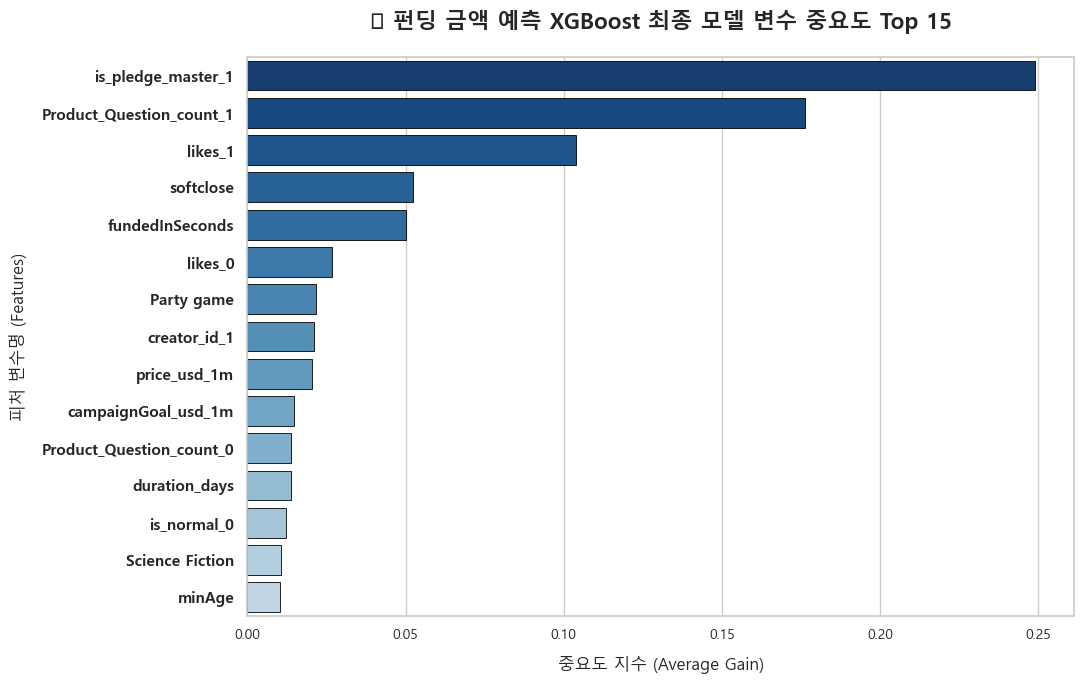


📋 [노션 기록용] 상위 15개 피처 중요도 수치 표
 1위 | is_pledge_master_1             : 0.2488
 2위 | Product_Question_count_1       : 0.1763
 3위 | likes_1                        : 0.1037
 4위 | softclose                      : 0.0522
 5위 | fundedInSeconds                : 0.0500
 6위 | likes_0                        : 0.0268
 7위 | Party game                     : 0.0217
 8위 | creator_id_1                   : 0.0209
 9위 | price_usd_1m                   : 0.0204
 10위 | campaignGoal_usd_1m            : 0.0148
 11위 | Product_Question_count_0       : 0.0138
 12위 | duration_days                  : 0.0137
 13위 | is_normal_0                    : 0.0122
 14위 | Science Fiction                : 0.0106
 15위 | minAge                         : 0.0102


In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# ----------------------------------------------------------------------
# 🎨 맷플롯립(Matplotlib) 한글 깨짐 방지 및 스타일 설정
# ----------------------------------------------------------------------
plt.rc('font', family='Malgun Gothic') # Windows용 (Mac은 'AppleGothic')
plt.rc('axes', unicode_minus=False)    # 마이너스 기호 깨짐 방지
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# ======================================================================
# 1. 100회 레이스 우승 파라미터로 최종 모델 한 번에 학습 (Full-Train)
# ======================================================================
best_params = {
    'n_estimators': 250,
    'max_depth': 7,
    'learning_rate': 0.021027170386626614,
    'subsample': 0.8781266277900482,
    'colsample_bytree': 0.5945378691232412,
    'reg_alpha': 0.039413284106814925,
    'reg_lambda': 0.5915920809926959,
    'min_child_weight': 9
}

# 최종 모델 객체 생성 및 전체 데이터 학습
champion_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)
champion_model.fit(X_best, y_log)

# ======================================================================
# 2. 변수 중요도(Feature Importance) 추출 및 데이터프레임 빌드
# ======================================================================
# XGBRegressor의 기본 중요도는 'gain'(트리 분할 시 감소하는 평균 손실) 기준입니다.
importances = champion_model.feature_importances_
feature_names = X_best.columns

# 데이터프레임 생성 후 내림차순 정렬
df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

# ======================================================================
# 3. 상위 15개 핵심 피처 시각화 (Horizontal Bar Plot)
# ======================================================================
top_n = 15
df_top = df_importance.head(top_n)

plt.figure(figsize=(11, 7))
colors = sns.color_palette("Blues_r", n_colors=top_n + 5) # 상위 변수 강조용 그라데이션

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_top, 
    palette=colors[:top_n],
    edgecolor='black',
    linewidth=0.6
)

# 그래프 디테일 고도화
plt.title(f'🏆 펀딩 금액 예측 XGBoost 최종 모델 변수 중요도 Top {top_n}', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('중요도 지수 (Average Gain)', fontsize=12, labelpad=10)
plt.ylabel('피처 변수명 (Features)', fontsize=12, labelpad=10)
plt.xticks(fontsize=10)
plt.yticks(fontsize=11, fontweight='semibold')
plt.tight_layout()

# 그래프 출력
plt.show()

# ======================================================================
# 4. 노션 기록용 텍스트 리스트 출력
# ======================================================================
print(f"\n📋 [노션 기록용] 상위 {top_n}개 피처 중요도 수치 표")
print("="*50)
for idx, row in df_top.iterrows():
    print(f" {idx+1}위 | {row['Feature']:<30} : {row['Importance']:.4f}")
print("="*50)

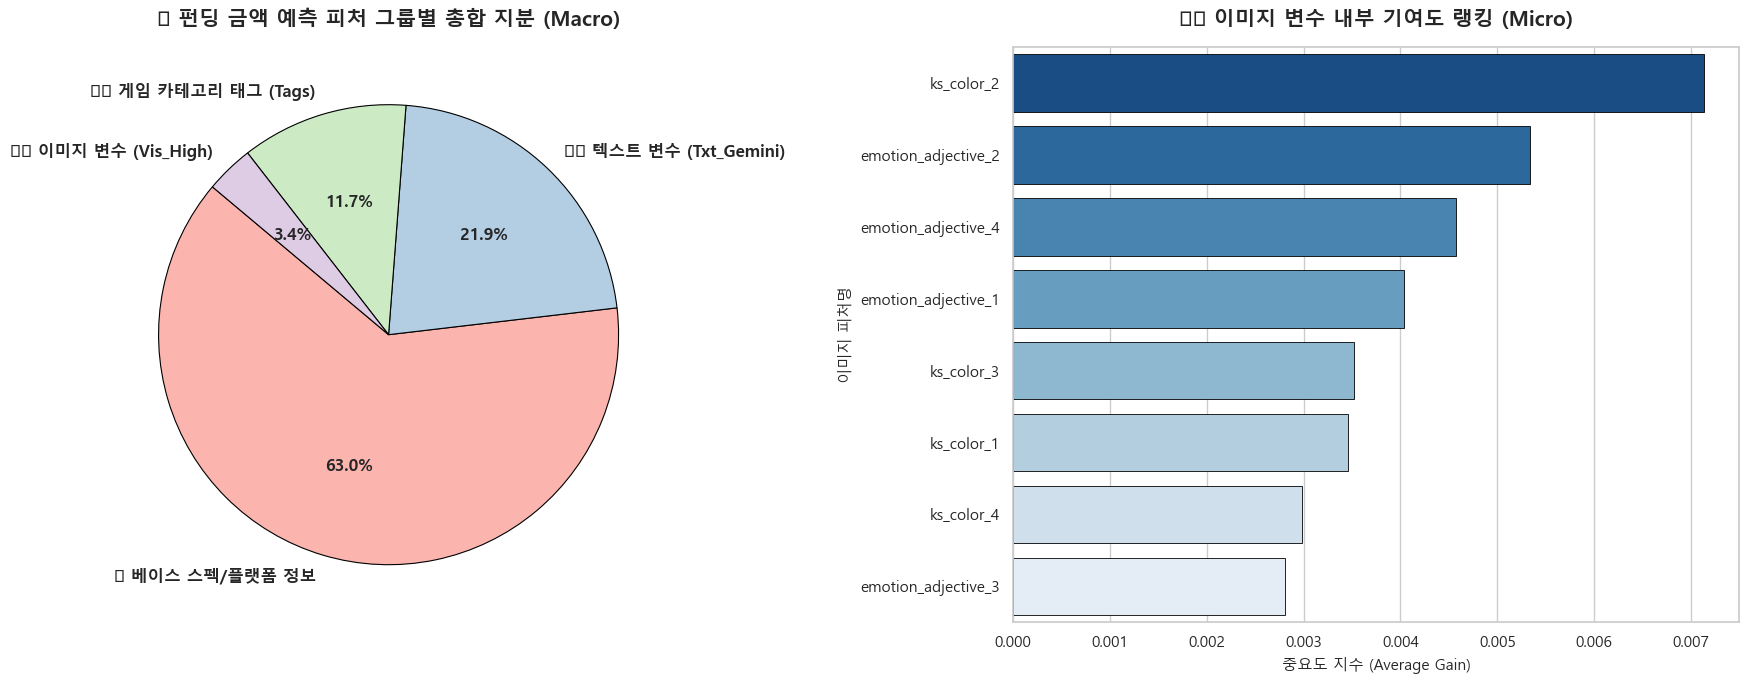


📋 [노션 기록용] 피처 그룹별 누적 지분 수치
 1위 | 📊 베이스 스펙/플랫폼 정보           : 62.97%
 2위 | ✍️ 텍스트 변수 (Txt_Gemini)    : 21.93%
 3위 | 🏷️ 게임 카테고리 태그 (Tags)      : 11.71%
 4위 | 🖼️ 이미지 변수 (Vis_High)      : 3.39%

🖼️ [노션 기록용] 이미지 변수 내 개별 기여도 순위
 1위 | ks_color_2                : 0.0071
 2위 | emotion_adjective_2       : 0.0053
 3위 | emotion_adjective_4       : 0.0046
 4위 | emotion_adjective_1       : 0.0040
 5위 | ks_color_3                : 0.0035
 6위 | ks_color_1                : 0.0035
 7위 | ks_color_4                : 0.0030
 8위 | emotion_adjective_3       : 0.0028


In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb

# 🎨 맷플롯립 한글 설정
plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)
sns.set_theme(style="whitegrid", font='Malgun Gothic')

# ======================================================================
# 1. 챔피언 모델 학습 및 중요도 추출 (기존 변수 및 파라미터 100% 동일)
# ======================================================================
best_params = {
    'n_estimators': 250, 'max_depth': 7, 'learning_rate': 0.021027170386626614,
    'subsample': 0.8781266277900482, 'colsample_bytree': 0.5945378691232412,
    'reg_alpha': 0.039413284106814925, 'reg_lambda': 0.5915920809926959, 'min_child_weight': 9
}

champion_model = xgb.XGBRegressor(**best_params, random_state=42, n_jobs=-1)
champion_model.fit(X_best, y_log)

df_importance = pd.DataFrame({
    'Feature': X_best.columns,
    'Importance': champion_model.feature_importances_
})

# ======================================================================
# 2. 피처 그룹(Group) 정의 및 매핑
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']
base_group = performance + game_properties + campaign_info + location + comment_info

vis_high_group = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4', 'emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']
txt_gemini_group = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']

def assign_group(feature_name):
    if feature_name in vis_high_group:
        return '🖼️ 이미지 변수 (Vis_High)'
    elif feature_name in txt_gemini_group:
        return '✍️ 텍스트 변수 (Txt_Gemini)'
    elif feature_name in base_group:
        return '📊 베이스 스펙/플랫폼 정보'
    else:
        return '🏷️ 게임 카테고리 태그 (Tags)'

df_importance['Group'] = df_importance['Feature'].apply(assign_group)

# 그룹별 중요도 합계 계산
df_group = df_importance.groupby('Group')['Importance'].sum().reset_index()
df_group = df_group.sort_values(by='Importance', ascending=False).reset_index(drop=True)

# ======================================================================
# 3. [시각화 1] 4大 피처 그룹별 총합 지분 (Pie Chart)
# ======================================================================
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

axes[0].pie(
    df_group['Importance'], 
    labels=df_group['Group'], 
    autopct='%1.1f%%', 
    startangle=140,
    colors=sns.color_palette("Pastel1"),
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 0.8}
)
axes[0].set_title('💸 펀딩 금액 예측 피처 그룹별 총합 지분 (Macro)', fontsize=15, fontweight='bold', pad=15)

# ======================================================================
# 4. [시각화 2] 이미지 변수(Vis_High) 내 개별 순위 (Bar Chart)
# ======================================================================
df_vis = df_importance[df_importance['Group'] == '🖼️ 이미지 변수 (Vis_High)'].sort_values(by='Importance', ascending=False)

sns.barplot(
    x='Importance', 
    y='Feature', 
    data=df_vis, 
    ax=axes[1],
    palette=sns.color_palette("Blues_r", n_colors=len(df_vis)),
    edgecolor='black',
    linewidth=0.6
)
axes[1].set_title('🖼️ 이미지 변수 내부 기여도 랭킹 (Micro)', fontsize=15, fontweight='bold', pad=15)
axes[1].set_xlabel('중요도 지수 (Average Gain)', fontsize=11)
axes[1].set_ylabel('이미지 피처명', fontsize=11)
axes[1].tick_params(axis='y', labelsize=11)

plt.tight_layout()
plt.show()

# ======================================================================
# 5. 노션 기록용 텍스트 매트릭스 출력
# ======================================================================
print("\n📋 [노션 기록용] 피처 그룹별 누적 지분 수치")
print("="*60)
for idx, row in df_group.iterrows():
    print(f" {idx+1}위 | {row['Group']:<25} : {row['Importance']*100:.2f}%")
print("="*60)

print("\n🖼️ [노션 기록용] 이미지 변수 내 개별 기여도 순위")
print("="*60)
for idx, row in df_vis.reset_index(drop=True).iterrows():
    print(f" {idx+1}위 | {row['Feature']:<25} : {row['Importance']:.4f}")
print("="*60)

In [18]:
import numpy as np
import pandas as pd
import warnings
import lightgbm as lgb
import optuna
import re
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, median_absolute_error, mean_squared_error, r2_score

# 경고 및 Optuna 로그 메시지 숨기기
warnings.filterwarnings('ignore', category=UserWarning)
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ======================================================================
# 1. 피처 세트 및 타깃 세팅 (XGBoost와 100% 동일한 대조군 환경)
# ======================================================================
performance = ['campaignGoal_usd_1m', 'price_usd_1m']
game_properties = ['minPlayers', 'maxPlayers', 'minAge', 'playTime']
campaign_info = ['isDiscounted', 'previous_campaigns_count', 'duration_days', 'fundedInSeconds', 'rewards_count', 'softclose']
location = ['currencySymbol_AUD', 'currencySymbol_CAD', 'currencySymbol_EUR', 'currencySymbol_GBP', 'currencySymbol_PLN', 'currencySymbol_USD']
comment_info = ['creator_id_0', 'creator_id_1', 'is_pledge_master_0', 'is_pledge_master_1', 'is_prior_backer_0', 'is_prior_backer_1', 'is_pathfinder_0', 'is_pathfinder_1', 'is_normal_0', 'is_normal_1', 'likes_0', 'likes_1']

base_features = performance + game_properties + campaign_info + location + comment_info
vis_high = ['ks_color_1', 'ks_color_2', 'ks_color_3', 'ks_color_4', 'emotion_adjective_1', 'emotion_adjective_2', 'emotion_adjective_3', 'emotion_adjective_4']
txt_gemini = ['Product_Question_count_0', 'Product_Question_count_1', 'Suggestion_Idea_count_0', 'Suggestion_Idea_count_1', 'Praise_Support_count_0', 'Praise_Support_count_1', 'Shipping_Fulfillment_count_0', 'Shipping_Fulfillment_count_1', 'Complaint_Refund_count_0', 'Complaint_Refund_count_1', 'Spam_Irrelevant_count_0', 'Spam_Irrelevant_count_1']
game_tags = ['4X', 'AR Next', 'ARNext26', 'Action', 'Adventure', 'Area Control', 'Asymmetric', 'Campaign', 'Card Game', 'Cats', 'Civilization', 'Collectible', 'Collectible Models', 'Competitive', 'Cooperative', 'Deck Building', 'Deduction', 'Dexterity', 'Dice Game', 'Digital', 'Economic', 'Educational', 'Exploration', 'Family', 'Fantasy', 'Feast', 'First-Timers', 'Game Components', 'History', 'Horror', 'Humor', 'Legacy', 'Logical', 'MOBA', 'Major Creators', 'Media', 'Modern', 'Multiplayer', 'Mythology', 'Narrative', 'OctoberFeast25', 'Paint', 'Party game', 'Political', 'Print and Play', 'RPG', 'Racing', 'Reprints', 'Resource management', 'Science Fiction', 'Set Collection', 'Sport', 'Strategy', 'Survival', 'TTRPG', 'Terrain Building', 'Tower Defense', 'Video Game', 'Video Game Theme', 'Wargame', 'WinterFeast2026', 'Worker placement', 'dinotuesday']

best_features = list(dict.fromkeys(base_features + vis_high + txt_gemini + game_tags))

# 💡 LightGBM 안전장치: 피처 이름에서 특수문자/공백 제거 및 변경
X_best = df_filtered[best_features].copy()
X_best.columns = [re.sub(r'[ ,\{\}:"\]\[\-]', '_', col) for col in X_best.columns]

col_target = 'fundsGathered_usd_1m'
y_original = df_filtered[col_target]
y_log = np.log1p(y_original)

kf = KFold(n_splits=5, shuffle=True, random_state=42)

# ======================================================================
# 2. STEP 1: Optuna 하이퍼파라미터 100회 탐색 시작 (LGBM 전용 스페이스)
# ======================================================================
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 150, 600, step=50),
        'max_depth': trial.suggest_int('max_depth', 4, 8),
        
        # 💡 LGBM의 핵심: 리프 노드의 최대 개수 (XGBoost의 max_depth와 상호작용 제어)
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.08, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 0.9),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 0.6),
        
        # 규제 강화를 통한 과적합 제어
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-2, 50.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-2, 50.0, log=True),
        
        # 💡 한 리프 노드가 가지기 위한 최소 데이터 수 (XGBoost의 min_child_weight 역할)
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 30),
        
        'random_state': 42,
        'n_jobs': -1,
        'verbose': -1 # 학습 로그 생략
    }
    
    cv_mae_scores = []
    for train_idx, test_idx in kf.split(X_best):
        X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
        y_tr_log = y_log.iloc[train_idx]
        
        model = lgb.LGBMRegressor(**params)
        model.fit(X_tr, y_tr_log)
        
        te_preds_real = np.expm1(model.predict(X_te))
        cv_mae_scores.append(mean_absolute_error(y_original.iloc[test_idx], te_preds_real))
        
    return np.mean(cv_mae_scores)

print("⚙️ [최종 라운드] Optuna 기반 LightGBM 100회 정밀 최적화 레이스 시작...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=100)

best_params = study.best_params
print(f"🎯 100회 탐색 완료! 최적 파라미터 조합: {best_params}\n" + "="*85)

# ======================================================================
# 3. STEP 2: 도출된 최적 파라미터 기반 5-Fold 전지표 검증 매트릭스 연산
# ======================================================================
print("📊 [STEP 2] 최적 LGBM 기반 5-Fold 최종 검증 연산 시작...\n" + "-"*85)

results_folds = []

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X_best), 1):
    X_tr, X_te = X_best.iloc[train_idx], X_best.iloc[test_idx]
    y_tr_log = y_log.iloc[train_idx]
    
    final_model = lgb.LGBMRegressor(**best_params, random_state=42, n_jobs=-1, verbose=-1)
    final_model.fit(X_tr, y_tr_log)
    
    tr_preds_real = np.expm1(final_model.predict(X_tr))
    te_preds_real = np.expm1(final_model.predict(X_te))
    
    y_tr_real = y_original.iloc[train_idx]
    y_te_real = y_original.iloc[test_idx]
    
    fold_res = {
        'tr_mae': mean_absolute_error(y_tr_real, tr_preds_real),
        'te_mae': mean_absolute_error(y_te_real, te_preds_real),
        'tr_r2': r2_score(y_tr_real, tr_preds_real),
        'te_r2': r2_score(y_te_real, te_preds_real),
        'tr_medae': median_absolute_error(y_tr_real, tr_preds_real),
        'te_medae': median_absolute_error(y_te_real, te_preds_real),
        'tr_rmse': np.sqrt(mean_squared_error(y_tr_real, tr_preds_real)),
        'te_rmse': np.sqrt(mean_squared_error(y_te_real, te_preds_real))
    }
    results_folds.append(fold_res)
    
    print(f"🔹 Fold {fold_idx} 성적 리포트")
    print(f"   - [MAE]  Train: {fold_res['tr_mae']:,.1f}$ | Test: {fold_res['te_mae']:,.1f}$")
    print(f"   - [R²]   Train: {fold_res['tr_r2']:.3f}  | Test: {fold_res['te_r2']:.3f}")
    print(f"   - [보조] Test MedAE: {fold_res['te_medae']:,.1f}$ | Test RMSE: {fold_res['te_rmse']:,.1f}$")
    print("-" * 85)

# ======================================================================
# 4. 최종 결과 종합 및 성적표 프린트
# ======================================================================
df_folds = pd.DataFrame(results_folds)
metrics_summary = df_folds.mean()

mae_gap = metrics_summary['te_mae'] - metrics_summary['tr_mae']
r2_gap = metrics_summary['tr_r2'] - metrics_summary['te_r2']

print("\n🏆 [최종 최적화 LightGBM 벤치마크 리포트]")
print("="*85)
print(f"⚙️ 0. 최적 하이퍼파라미터 (Optuna): {best_params}")
print("-" * 85)
print(f"📊 1. 평균 절대 오차 (MAE - 핵심 지표)")
print(f"   - Train MAE : {metrics_summary['tr_mae']:,.2f} 달러")
print(f"   - Test MAE  : {metrics_summary['te_mae']:,.2f} 달러")
print(f"   - 💡 MAE 갭  : {mae_gap:,.2f} 달러")
print("-" * 85)
print(f"📈 2. 결정계수 (R² Score - 통계적 과적합 판정 척도)")
print(f"   - Train R²  : {metrics_summary['tr_r2']:.4f}")
print(f"   - Test R²   : {metrics_summary['te_r2']:.4f}")
print(f"   - 💡 R² 갭   : {r2_gap:.4f}")
print("-" * 85)
print(f"🎯 3. 중간값 절대 오차 (MedAE - 창작자 체감 중간 오차)")
print(f"   - Train MedAE: {metrics_summary['tr_medae']:,.2f} 달러")
print(f"   - Test MedAE : {metrics_summary['te_medae']:,.2f} 달러")
print("-" * 85)
print(f"🛡️ 4. 평균 제곱근 오차 (RMSE - 대형 오판 위험도 감시)")
print(f"   - Train RMSE : {metrics_summary['tr_rmse']:,.2f} 달러")
print(f"   - Test RMSE  : {metrics_summary['te_rmse']:,.2f} 달러")
print("="*85)

c:\Users\seon\anaconda3\lib\site-packages\dask\dataframe\__init__.py:42: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


⚙️ [최종 라운드] Optuna 기반 LightGBM 100회 정밀 최적화 레이스 시작...
🎯 100회 탐색 완료! 최적 파라미터 조합: {'n_estimators': 250, 'max_depth': 5, 'num_leaves': 96, 'learning_rate': 0.033805462291327804, 'subsample': 0.7118994656801855, 'colsample_bytree': 0.48607734226204974, 'reg_alpha': 0.3181547491389111, 'reg_lambda': 0.05798332427034437, 'min_child_samples': 12}
📊 [STEP 2] 최적 LGBM 기반 5-Fold 최종 검증 연산 시작...
-------------------------------------------------------------------------------------
🔹 Fold 1 성적 리포트
   - [MAE]  Train: 10,385.1$ | Test: 21,876.7$
   - [R²]   Train: 0.974  | Test: 0.859
   - [보조] Test MedAE: 5,333.8$ | Test RMSE: 48,229.9$
-------------------------------------------------------------------------------------
🔹 Fold 2 성적 리포트
   - [MAE]  Train: 10,871.4$ | Test: 21,768.9$
   - [R²]   Train: 0.970  | Test: 0.848
   - [보조] Test MedAE: 4,831.7$ | Test RMSE: 51,051.6$
-------------------------------------------------------------------------------------
🔹 Fold 3 성적 리포트
   - [MAE]  Train: 10,228.7